<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/gesture_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ignore this block if you are running locally
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [13]:
os.chdir("drive/My Drive/Colab Notebooks/ASSN3")

# imported required packages. Add the one you need.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from PIL import Image

import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


from image_dataloader import GestureSequenceDataset
dataset_path = "./data/train"




# Video/Images Classification

In [15]:
# TODO 1
# Create training and testing dataset from the image files
# Transform your images before creating data loaders

#Resized images so they were a uniform size. Looked at code from this link for information about transforms and resizing.
# https://medium.com/@MarkAiCode/resize-images-with-pytorch-a-comprehensive-guide-b9025b8fe79d
#Normalization values/discussion taken from
# https://discuss.pytorch.org/t/understanding-transform-normalize/21730

myTransform = transforms.Compose([
      transforms.Resize((120, 160)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.5], std=[0.5])
])

trainSet = GestureSequenceDataset(root_dir="./data/train", transform=myTransform)
train_loader = DataLoader(trainSet, batch_size=32, shuffle=True, num_workers=4)
print("Number of Batches =", len(train_loader))



Number of Batches = 21


In [16]:
# import packages for building sequential model
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F



In [17]:
class GestureRecognitionModel(nn.Module):
    def __init__(self, num_classes):
        super(GestureRecognitionModel, self).__init__()
        # TODO 2: construct your own model. CNNs+LSTM is recommended
        #Started here
        #https://www.kaggle.com/code/deshwalmahesh/pytorch-detailed-tutorial-for-beginners-using-cnn
        #Also looked at
        #https://www.kaggle.com/code/krishanudb/tutorial-on-convolutional-nets-in-pytorch
        #padding keeps the convolutions from shrinking the output.


        self.cnn = nn.Sequential(
          nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2, stride=2),

          nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1),
          nn.BatchNorm2d(32),
          nn.ReLU(),

          nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1),
          nn.BatchNorm2d(32),
          nn.ReLU(),

          nn.MaxPool2d(kernel_size=2, stride=2),
          )

        #I read about LSTMs here:
        #https://www.kaggle.com/code/kanncaa1/long-short-term-memory-with-pytorch
        self.lstm = nn.LSTM(input_size=38400, hidden_size = 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)


    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()  # Shape: (batch_size, seq_len, c, h, w)

        # TODO 3: write your feed forward network
        #Channels, height, width
        #

        # CNNs don't have a time dimension, so multiply batch size and seq_len for input
        flat = batch_size * seq_len
        x = x.view(flat, c, h, w)
        x = self.cnn(x)

        #Reshape the output back and reinclude the time dimension as seq_len
        x = x.view(batch_size, seq_len, -1)
        x, y = self.lstm(x)

        #We only need the last time step of the LSTM output.
        x = x[:, -1, :]
        x = self.fc(x)

        return x


In [ ]:
# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model, loss function, and optimizer
model = GestureRecognitionModel(num_classes=5).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # For multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # change the learning rate as you want

NVIDIA A100-SXM4-40GB
True
cuda


In [ ]:
# TODO 4: train your model with sequnce of images, you should aim for at least
# 45% training accuracy. Report your training accuracy.


num_epochs =  20

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Loop over each batch
    for i, (sequences, labels) in enumerate(train_loader):
        sequences, labels = sequences.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(sequences)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Optimize the model
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        running_loss += loss.item()

    # Print statistics for the epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

    # it is recommand to save the model regulary during training if you don't have a lof of computational resource
    if (epoch%5 ==0) or (epoch==19): # change the saving frequency as you want
        model_path = os.path.join("/content/drive/My Drive/Colab Notebooks/ASSN3", 'model_configs', f'image_lstm_model_{epoch+1}.pth')
        torch.save(model.state_dict(), model_path)


Epoch [1/20], Loss: 1.3748, Accuracy: 49.47%
Epoch [2/20], Loss: 1.3264, Accuracy: 56.56%
Epoch [3/20], Loss: 1.2702, Accuracy: 57.16%
Epoch [4/20], Loss: 1.2160, Accuracy: 61.24%
Epoch [5/20], Loss: 1.1729, Accuracy: 61.09%
Epoch [6/20], Loss: 1.1396, Accuracy: 64.56%
Epoch [7/20], Loss: 1.1266, Accuracy: 64.56%
Epoch [8/20], Loss: 1.0825, Accuracy: 68.63%
Epoch [9/20], Loss: 1.0752, Accuracy: 64.25%
Epoch [10/20], Loss: 1.0210, Accuracy: 71.95%
Epoch [11/20], Loss: 0.9717, Accuracy: 74.21%
Epoch [12/20], Loss: 0.9425, Accuracy: 74.66%
Epoch [13/20], Loss: 0.9289, Accuracy: 75.41%
Epoch [14/20], Loss: 0.8856, Accuracy: 77.68%
Epoch [15/20], Loss: 0.8576, Accuracy: 78.88%
Epoch [16/20], Loss: 0.7970, Accuracy: 80.09%
Epoch [17/20], Loss: 0.7622, Accuracy: 81.75%
Epoch [18/20], Loss: 0.7574, Accuracy: 82.05%
Epoch [19/20], Loss: 0.7156, Accuracy: 84.92%
Epoch [20/20], Loss: 0.7203, Accuracy: 82.65%


In [ ]:
# TODO 5
# create test data loader

# Load the specified trained model (if you have saved muliple checkpoint during training)
#model = GestureRecognitionModel(num_classes=5)
model.load_state_dict(torch.load("./model_configs/image_lstm_model_20.pth"))  # Load the desired saved model weights, change the path if needed
model.eval()  # Set the model to evaluation mode


In [ ]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

gesture_labels = {0: "Swipe Left", 1: "Swipe Right", 2: "Stop", 3: "Thumbs Up", 4: "Thumbs Down"}
predictions = []
actualLabels = []

testSet = GestureSequenceDataset(root_dir="./data/val", transform=myTransform)
test_loader = DataLoader(testSet, batch_size=32, shuffle=False, num_workers=4)


# TODO 6: evaluate your model on the test dataset
with torch.no_grad():  # No gradients needed for inference

    for images, labels in test_loader:
      #Move the images and labels to the GPU
      images, labels = images.to(device), labels.to(device)

      modelOutputs = model(images)
      #Toss the first output, we only want the maximum along the first dimension
      _, maxOutput = torch.max(modelOutputs,dim=1)

      predictions.append(maxOutput.cpu())
      actualLabels.append(labels.cpu())

predictions = torch.cat(predictions, dim=0)
actualLabels = torch.cat(actualLabels, dim=0)
labels = actualLabels
# TODO 7: Report precision, recall, accuracy, F1 score, and create a confusion matrix on the test set, showing the confusions between labels.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

truePositives = [0,0,0,0,0]
falseNegatives = [0,0,0,0,0]
falsePositives = [0,0,0,0,0]


for index in range(len(labels)):
  if labels[index] == predictions[index]:
    truePositives[labels[index]] +=1;
  else:
    falsePositives[labels[index]] +=1
    falseNegatives[labels[index]] +=1

totalCorrect = 0;

for index in range(5):
  if truePositives[index] + falsePositives[index] != 0:
    precision = truePositives[index] / (truePositives[index] + falsePositives[index])
  else:
    precision = 0
  if truePositives[index] + falseNegatives[index] != 0:
    recall = truePositives[index] / (truePositives[index] + falseNegatives[index])
  else:
    recall = 0
  if precision + recall != 0:
    f1 = 2 * (precision * recall) / (precision + recall)
  else:
    f1 = 0
  totalCorrect += truePositives[index]

accuracy = totalCorrect / len(labels)

print(f"Recall = {recall:.2f}")
print(f"Precision = {precision:.2f}")
print(f"F1 = {f1:.2f}")
print(f"Accuracy = {accuracy:.2f}")

#Use of Seaborn and confusion map formatting from here:
#https://www.kaggle.com/code/agungor2/various-confusion-matrix-plots

confused = confusion_matrix(labels, predictions)

plt.figure(figsize=(10,10))
sns.heatmap(confused, cmap="Blues", annot=True)
plt.xlabel("Prediction")
plt.ylabel("Actual Label")
plt.title("A Confusion Matrix for Gestures")
plt.show()


# Hand Landmarks Classification

In [40]:
from landmark_dataloader import HandLandMarkDataset
import ast

#Read this on K-fold cross validation
#https://www.kaggle.com/code/satishgunjal/tutorial-k-fold-cross-validation R

train_landmark_path = "./train_landmarks.csv" # change the path as you needed
test_landmark_path = "./val_landmarks.csv"


train_data = pd.read_csv(train_landmark_path)
test_data = pd.read_csv(test_landmark_path)

train_data['landmarks'] = train_data['landmarks'].apply(ast.literal_eval)
test_data['landmarks'] = test_data['landmarks'].apply(ast.literal_eval)

train_data = train_data[train_data['landmarks'].apply(lambda x: len(x) > 0)].reset_index(drop=True)
test_data = test_data[test_data['landmarks'].apply(lambda x: len(x) > 0)].reset_index(drop=True)
train_data_folder = train_data['instance']
test_data_folder = test_data['instance']

#TODO 10: create the train and test dataloader for the hand landmarks

trainSetLandmarks = HandLandMarkDataset(train_data,"landmarks","instance")
testSetLandmarks = HandLandMarkDataset(test_data, "landmarks","instance")
train_loader_landmarks = DataLoader(trainSetLandmarks, batch_size=32, shuffle=True, num_workers=6)
test_loader_landmarks = DataLoader(testSetLandmarks, batch_size=32, num_workers=6)


Total rows in dataset after filtering: 19471
Total rows in dataset after filtering: 19471
Total rows in dataset after filtering: 3000
Total rows in dataset after filtering: 3000


In [41]:

class LandmarkClassifier(nn.Module):
    def __init__(self, input_size=63, hidden_size= 126, num_layers= 2, num_classes=5, dropout=0.30): # change the hyper parameter as you need
        """
        LSTM Model for hand gesture classification.

        Args:
            input_size (int): Number of input features per time step (21 joints * 3 coordinates = 63).
            hidden_size (int): Number of hidden units in the LSTM.
            num_layers (int): Number of stacked LSTM layers.
            num_classes (int): Number of gesture classes.
            dropout (float): Dropout rate for regularization.
        """

        # TODO 11: create a sequential model for hand landmarks recognition
        super(LandmarkClassifier, self).__init__()

        #Use the parameters from above to create the LSTM.
        self.lstm = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
      #Five possible outputs
        self.fc = nn.Linear(126,5)

    def forward(self, x):
        """
        Forward pass of the LSTM model.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, num_joints * coords).

        Returns:
            Tensor: Logits of shape (batch_size, num_classes).
        """


        # TODO 12: write your feed forward network
        lstmOutput, _ = self.lstm(x)
        output = self.fc(lstmOutput[:, -1, :])

        return output

In [42]:
# Define model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LandmarkClassifier(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # tuning the learning rate and change number of epoches as you need
num_epochs = 50 # set the number of epochs

# TODO 13: Train your model and report the training accuracy
# Training loop
for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (sequences, labels, original_index) in enumerate(train_loader_landmarks):

        sequences, labels = sequences.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(sequences)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Optimize the model
        optimizer.step()

        # Calculate accuracy
        predicted = torch.argmax(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        running_loss += loss.item()

    # Print statistics for the epoch
    epoch_loss = running_loss / len(train_loader_landmarks)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

    # regularly save model configurations
    if (epoch%5 ==0) or (epoch == 49):
        torch.save(model.state_dict(), f'./model_configs/landmark_recognition_model_{epoch+1}.pth')  # Save model


/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.long)  # Ensure label is long for classification
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.

Epoch [1/50], Loss: 1.5196, Accuracy: 40.22%


/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Co

Epoch [2/50], Loss: 0.9537, Accuracy: 70.42%


/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Co

...

Epoch [48/50], Loss: 0.3334, Accuracy: 91.22%


/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.long)  # Ensure label is long for classi

Epoch [49/50], Loss: 0.3362, Accuracy: 91.83%


/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.long)  # Ensure label is long for classification
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.

Epoch [50/50], Loss: 0.3700, Accuracy: 90.76%


In [43]:
# Load the specified trained model
#model = LSTMLandmarkClassifier(num_classes=5)
model.load_state_dict(torch.load("/content/drive/My Drive/Colab Notebooks/ASSN3/model_configs/landmark_recognition_model_50.pth"))  # Load the desired saved model weights, change the path if needed
model.eval()  # Set the model to evaluation mode

LandmarkClassifier(
  (lstm): LSTM(63, 126, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=126, out_features=5, bias=True)
)

/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(sequence, dtype=torch.float32)
/content/drive/MyDrive/Colab Notebooks/ASSN3/landmark_dataloader.py:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.long)  # Ensure label is long for classi

Recall = 100.0
Precision = 100.0
F1 = 100.0
Accuracy = 88.0


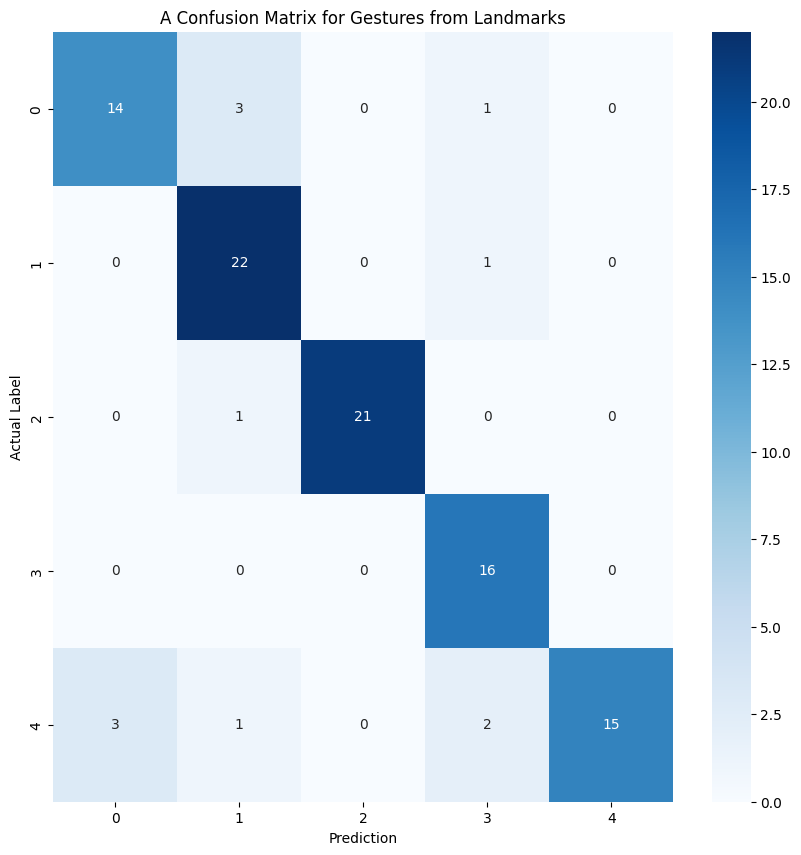

In [47]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

gesture_labels = {0: "Swipe Left", 1: "Swipe Right", 2: "Stop", 3: "Thumbs Up", 4: "Thumbs Down"}
predictions = []
actualLabels = []

with torch.no_grad():  # No gradients needed for inference
# TODO 14: test your model and report precision, recall, accuracy, F1 score, and create a confusion matrix on the test set, showing the confusions between labels.

    for sequence, label, idx in test_loader_landmarks:
      sequence, label = sequence.to(device), label.to(device)

      outputs = model(sequence)
      _, maxOutput = torch.max(outputs, dim=1)

      predictions.append(maxOutput.cpu())
      actualLabels.append(label.cpu())

predictions = torch.cat(predictions, dim=0)
actualLabels = torch.cat(actualLabels, dim=0)
labels = actualLabels


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

truePositives = [0,0,0,0,0]
falseNegatives = [0,0,0,0,0]
falsePositives = [0,0,0,0,0]


for index in range(len(labels)):
  if labels[index] == predictions[index]:
    truePositives[labels[index]] +=1;
  else:
    falsePositives[predictions[index]] +=1
    falseNegatives[predictions[index]] +=1

totalCorrect = 0;

for index in range(5):
  if truePositives[index] + falsePositives[index] != 0:
    precision = truePositives[index] / (truePositives[index] + falsePositives[index])
  else:
    precision = 0
  if truePositives[index] + falseNegatives[index] != 0:
    recall = truePositives[index] / (truePositives[index] + falseNegatives[index])
  else:
    recall = 0
  if precision + recall != 0:
    f1 = 2 * (precision * recall) / (precision + recall)
  else:
    f1 = 0
  totalCorrect += truePositives[index]

accuracy = totalCorrect / len(labels)

print(f"Recall = {(recall*100)}")
print(f"Precision = {(precision*100)}")
print(f"F1 = {(f1*100)}")
print(f"Accuracy = {(100*accuracy)}")

confused = confusion_matrix(labels, predictions)

plt.figure(figsize=(10,10))
sns.heatmap(confused, cmap="Blues", annot=True)
plt.xlabel("Prediction")
plt.ylabel("Actual Label")
plt.title("A Confusion Matrix for Gestures from Landmarks")
plt.show()



# TODO 15: Comaprison between the models:
Compare the results from the model you trained for sequential images and hand landmarks. How much time and how many epochs did it take for you to achieve the required training accuracy (45%)?  If there is a discrepancy, what are the reasons? Please also report the computing hardware resource you used for this assignment (CPU/GPU).

The model trained for sequential images converges much more slowly and was less accurate than the one trained on hand landmarks. The one for hand landmarks only took two epochs, while the one for sequential images started at 49% for the first epoch but had a lower accuracy at the end.



# visulization helper for images

In [ ]:
# Visualize multiple frames from the sequence
frames_to_display = 30  # Number of frames to visualize
test_dataset_root = ''

fig, axes = plt.subplots(1, frames_to_display, figsize=(30, 10))
folder_path_key = test_data_folder[90].split('_000')[0]
for image_folder_name in os.listdir(test_dataset_root):
    if folder_path_key in image_folder_name:
        image_folder_path = os.path.join(test_dataset_root, image_folder_name)

image_names = sorted(os.listdir(image_folder_path))
# Load and display each frame
for i in range(frames_to_display):

    image_path = os.path.join(image_folder_path, image_names[i])
    # print(image_path)
    # Open and transform the image
    image = Image.open(image_path).convert("L")
    image_tensor = transform(image)
    image_np = image_tensor.numpy().transpose(1, 2, 0)

    # Plot image
    axes[i].imshow(image_np)
    axes[i].axis('off')  # Hide axis for clarity
